# Paso 1: Acceso y Preparación de los Datos

En esta sección, vamos a cargar las tres tablas de datos (`visits`, `orders`, `costs`) desde los archivos CSV y las almacenaremos en variables pandas. Luego, ajustaremos los tipos de datos y verificaremos duplicados y valores faltantes en los datos.

## a) Carga las tres tablas y almacénalas en variables pandas

Primero, cargaremos las tres tablas de datos desde los archivos CSV y las almacenaremos en variables de tipo `pandas.DataFrame`.

In [1]:
import pandas as pd
import os

# Cargar los datos
df_visits = pd.read_csv('../data/raw/visits_log_us.csv')
df_orders = pd.read_csv('../data/raw/orders_log_us.csv')
df_costs = pd.read_csv('../data/raw/costs_us.csv')

# Verificar las primeras filas 
print(df_visits.head())
print(df_orders.head())
print(df_costs.head())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06

In [2]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [3]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [4]:
df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB



---

## b) Ajuste de los Tipos de Datos

En este paso, ajustaremos los tipos de datos de las columnas, asegurándonos de que las columnas de fecha estén en formato `datetime`, y que los identificadores como `Uid`, `Source_Id`, etc., estén en el tipo adecuado (`int` o `string`).

In [5]:
df_orders.columns= [columna.lower().replace(' ', '_') for columna in df_orders.columns]
df_visits.columns= [columna.lower().replace(' ', '_') for columna in df_visits.columns]
df_costs.columns= [columna.lower().replace(' ', '_') for columna in df_costs.columns]

In [6]:
# Convertir las columnas de fechas a datetime
df_visits['start_ts'] = pd.to_datetime(df_visits['start_ts'])
df_visits['end_ts'] = pd.to_datetime(df_visits['end_ts'])
df_orders['buy_ts'] = pd.to_datetime(df_orders['buy_ts'])
df_costs['dt'] = pd.to_datetime(df_costs['dt'])


---

## c) Verifica duplicados y valores faltantes; documenta tu estrategia de limpieza

Verificaremos si hay filas duplicadas o valores faltantes en los datos. Usaremos la función `exploracion_iniical(df)` para explorar cada conjunto de datos y determinar qué acciones tomar (eliminar duplicados o imputar valores faltantes).

In [7]:
# Definir la función de exploración inicial
def exploracion_iniical(df):
    print('-'*30 + 'Primeras filas' + '-'*30)
    print(df.head(10))  # Muestra las primeras filas
    print('-'*30 + 'Estructura de la tabla' + '-'*30)
    print(df.info())  # Muestra la estructura del DataFrame (tipos de datos, etc.)
    print('-'*30 + 'Duplicados' + '-'*30)
    print(df.duplicated().sum())  # Muestra el número de filas duplicadas
    print('-'*30 + 'Ausentes' + '-'*30)
    print(df.isna().sum())  # Muestra el número de valores faltantes

In [8]:
# Aplicar la función
print("Exploración de 'df_visits'")
exploracion_iniical(df_visits)

Exploración de 'df_visits'
------------------------------Primeras filas------------------------------
    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   
5  desktop 2017-09-03 21:36:00          5 2017-09-03 21:35:00   
6  desktop 2018-01-30 12:09:00          1 2018-01-30 11:13:00   
7    touch 2017-11-05 15:15:00          3 2017-11-05 15:14:00   
8  desktop 2017-07-19 10:44:00          3 2017-07-19 10:41:00   
9  desktop 2017-11-08 13:43:00          5 2017-11-08 13:42:00   

                    uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  


In [9]:
print("\nExploración de 'df_orders'")
exploracion_iniical(df_orders)


Exploración de 'df_orders'
------------------------------Primeras filas------------------------------
               buy_ts  revenue                   uid
0 2017-06-01 00:10:00    17.00  10329302124590727494
1 2017-06-01 00:25:00     0.55  11627257723692907447
2 2017-06-01 00:27:00     0.37  17903680561304213844
3 2017-06-01 00:29:00     0.55  16109239769442553005
4 2017-06-01 07:58:00     0.37  14200605875248379450
5 2017-06-01 08:43:00     0.18  10402394430196413321
6 2017-06-01 08:54:00     1.83  12464626743129688638
7 2017-06-01 09:22:00     1.22   3644482766749211722
8 2017-06-01 09:22:00     3.30  17542070709969841479
9 2017-06-01 09:23:00     0.37   1074355127080856382
------------------------------Estructura de la tabla------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  dat

In [10]:
print("\nExploración de 'df_costs'")
exploracion_iniical(df_costs)


Exploración de 'df_costs'
------------------------------Primeras filas------------------------------
   source_id         dt  costs
0          1 2017-06-01  75.20
1          1 2017-06-02  62.25
2          1 2017-06-03  36.53
3          1 2017-06-04  55.00
4          1 2017-06-05  57.08
5          1 2017-06-06  40.39
6          1 2017-06-07  40.59
7          1 2017-06-08  56.63
8          1 2017-06-09  40.16
9          1 2017-06-10  43.24
------------------------------Estructura de la tabla------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
None
------------------------------Duplicados------------------

1. **Duplicados**: 
   - Se verificó si existían filas duplicadas en los conjuntos de datos utilizando la función `duplicated()`. No se encontraron filas duplicadas en ninguna de las tablas (`df_visits`, `df_orders`, `df_costs`).

2. **Valores Faltantes**: 
   - Se verificó si había valores faltantes en los datos utilizando la función `isna().sum()`. Todos los conjuntos de datos están completos y no presentan valores nulos.

### **Estrategia de limpieza**:
Dado que no se encontraron duplicados ni valores faltantes en los datos:
- No fue necesario realizar ninguna acción de limpieza adicional en estos aspectos.

---

# Paso 2: Cálculo de Métricas e Informes

En esta sección, vamos a calcular varias métricas clave relacionadas con las visitas de los usuarios, como **DAU**, **WAU**, **MAU**, la **duración de cada sesión** y la **frecuencia con la que los usuarios regresan**.

## A. Visitas

A continuación, analizaremos las visitas a la página utilizando las siguientes métricas clave:

1. **DAU (Usuarios Activos Diarios)**: Número de usuarios únicos por día.
2. **WAU (Usuarios Activos Semanales)**: Número de usuarios únicos por semana.
3. **MAU (Usuarios Activos Mensuales)**: Número de usuarios únicos por mes.
4. **Sesiones por Día**: ¿Cuántas sesiones hay por día? Un usuario puede tener más de una sesión.
5. **Duración de la Sesión**: ¿Cuál es la duración de cada sesión? (End_Ts - Start_Ts).
6. **Frecuencia de Regreso de los Usuarios**: ¿Con qué frecuencia regresan los usuarios?

## A.1) ¿Cuántas personas visitan la página cada día, semana y mes? (DAU, WAU, MAU)

En esta sección, vamos a calcular los usuarios activos diarios (DAU), semanales (WAU) y mensuales (MAU). Estos indicadores nos permiten analizar la frecuencia de visitas por parte de los usuarios en distintos períodos de tiempo.


In [11]:
# Creamos nuevas columnas para el mes, semana y fecha de la sesión
df_visits['sesion_mes'] = pd.to_datetime(df_visits['start_ts'].dt.strftime('%Y-%m-01'))
df_visits['sesion_semana'] = df_visits['start_ts'].dt.isocalendar().week
df_visits['sesion_fecha'] = df_visits['start_ts'].dt.date

In [12]:
df_visits

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27
...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017-07-01,30,2017-07-29
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-01,4,2018-01-25
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018-03-01,9,2018-03-03
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017-11-01,44,2017-11-02


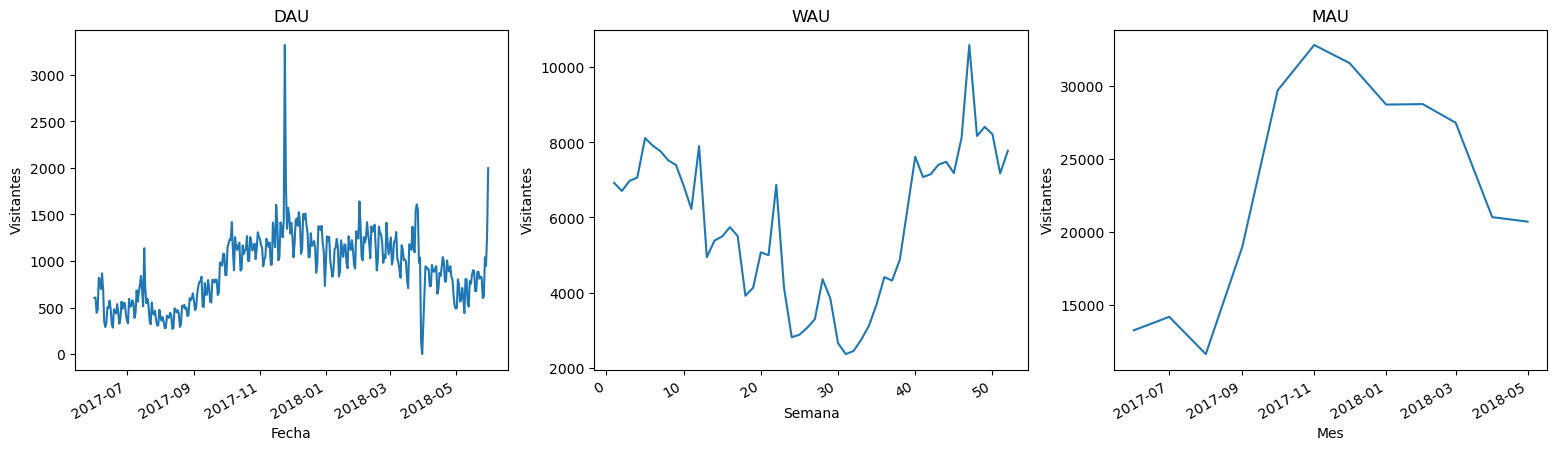

In [13]:
# Calcular DAU, WAU, MAU
dau = df_visits.groupby('sesion_fecha').agg({'uid': 'nunique'})
wau = df_visits.groupby('sesion_semana').agg({'uid': 'nunique'})
mau = df_visits.groupby('sesion_mes').agg({'uid': 'nunique'})

# Graficar los resultados
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
ax[0].plot(dau)
ax[0].set(title='DAU', xlabel='Fecha', ylabel='Visitantes')
ax[1].plot(wau)
ax[1].set(title='WAU', xlabel='Semana', ylabel='Visitantes')
ax[2].plot(mau)
ax[2].set(title='MAU', xlabel='Mes', ylabel='Visitantes')

fig.autofmt_xdate(rotation=30)
plt.show()

En esta sección, se presentan los gráficos de las métricas **DAU** (Usuarios Activos Diarios), **WAU** (Usuarios Activos Semanales) y **MAU** (Usuarios Activos Mensuales). Estas métricas nos permiten analizar el tráfico de usuarios en la página web en diferentes períodos de tiempo.

El gráfico de **DAU** muestra el número de usuarios únicos que visitan la página cada día. Se observan las siguientes características:

- En mayo de 2018, hay un aumento notorio de visitas, lo que podría ser indicativo de una campaña o evento que atrajo a muchos usuarios.
- A lo largo del tiempo, se notan cambios diarios en las visitas, lo cual es común en la actividad diaria de una página web.

El gráfico de **WAU** presenta la cantidad de usuarios únicos por semana. Este gráfico muestra:

- En noviembre de 2017, se identifican algunas semanas con un número elevado de visitas, posiblemente relacionadas con promociones u otros eventos.
- Las fluctuaciones son menores comparadas con DAU, ya que se agrupan las visitas durante toda la semana.

El gráfico de **MAU** muestra las visitas de usuarios a lo largo de los meses. Las observaciones clave son:

- **Crecimiento durante el tercer trimestre de 2017**: Se observa un aumento considerable de visitas en ese período, alcanzando su pico en septiembre de 2017.
- **Estabilidad en el largo plazo**: Las fluctuaciones son más suaves que en los gráficos de DAU y WAU, lo que proporciona una visión más generalizada del comportamiento de los usuarios a lo largo del tiempo.

---


## A.2) ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión)

Aquí vamos a calcular cuántas sesiones hay por día. Teniendo en cuenta que un usuario puede tener varias sesiones, contaremos todas las sesiones realizadas por día.

In [14]:
# Calcular sesiones por usuario y día
sesiones_por_usuario = df_visits.groupby('sesion_fecha').agg({'uid': ['count', 'nunique']})

# Renombramos las columnas para hacerlas más comprensibles
sesiones_por_usuario.columns = ['n_sesion', 'n_usuarios']

# Mostrar los resultados
sesiones_por_usuario

,n_sesion,n_usuarios
sesion_fecha,,
2017-06-01,664,605
2017-06-02,658,608
2017-06-03,477,445
2017-06-04,510,476
2017-06-05,893,820
...,...,...
2018-05-27,672,620
2018-05-28,1156,1039
2018-05-29,1035,948


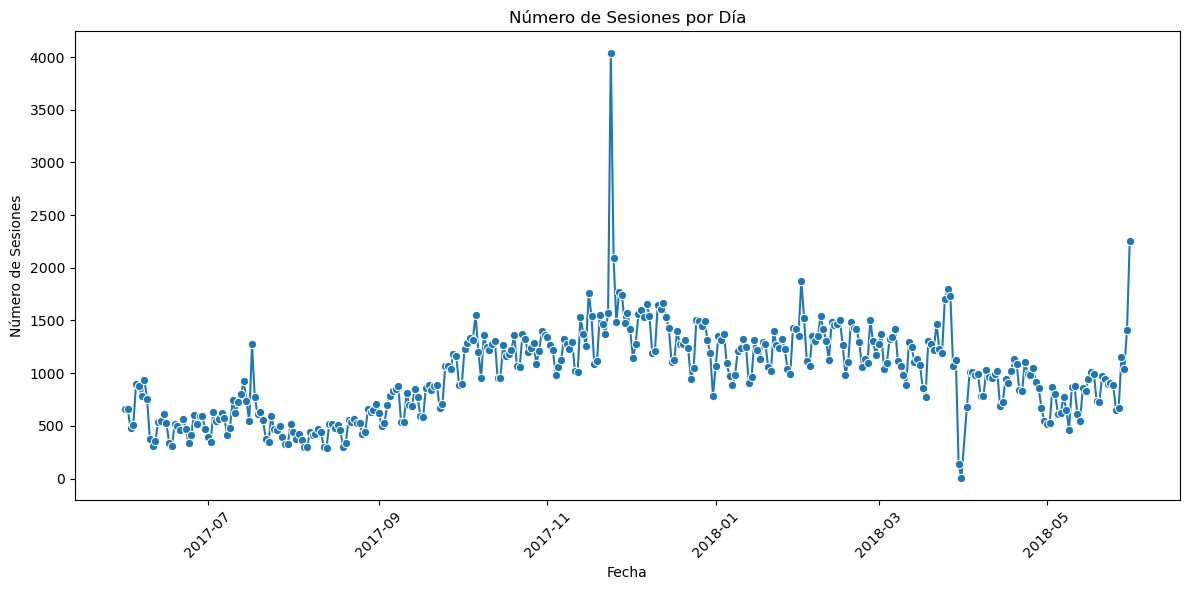

In [15]:
import seaborn as sns
# Graficar el total de sesiones por día
plt.figure(figsize=(12, 6))
sns.lineplot(data=sesiones_por_usuario, x=sesiones_por_usuario.index, y='n_sesion', marker='o')

# Configurar el gráfico
plt.title('Número de Sesiones por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Sesiones')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

**Picos Notables:**

Se observan picos significativos en ciertos días, enero de 2018 y mayo de 2018, donde el número de sesiones se eleva de forma notable. Este aumento podría estar relacionado con campañas específicas, promociones, o eventos que generaron un incremento en la actividad en la plataforma. El pico más alto fue a finales del 2017, es especialmente destacado. Puede deberse a festividades al final del año.

Estos picos sugieren que ciertos días la plataforma tuvo una cantidad alta de usuarios o sesiones, lo cual podría indicar un evento específico que atrajo a más usuarios.

**Variabilidad Diaria:**

Se observa una fluctuación constante en el número de sesiones a lo largo del tiempo, lo que es común en las actividades diarias de una plataforma web. Algunas fechas tienen más sesiones debido a la actividad de los usuarios, mientras que otras tienen menos.

**Tendencia General:**

La tendencia general muestra un aumento paulatino en el número de sesiones desde 2017 hasta 2018, lo que sugiere que la plataforma fue ganando más usuarios con el tiempo. Sin embargo, esta tendencia es interrumpida por los picos y las caídas repentinas. 

**Frecuencia de Sesiones:**

Es importante notar que un usuario puede tener más de una sesión por día, lo que significa que el número de sesiones no es necesariamente igual al número de usuarios. Algunos usuarios regresan a la plataforma varias veces al día, lo que genera múltiples sesiones por usuario. Esto se ve reflejado en los valores de sesiones, que pueden ser significativamente más altos que el número de usuarios activos diarios.

---

## A.3) ¿Cuál es la duración de cada sesión? (End_Ts - Start_Ts)

En este paso, vamos a calcular la duración de cada sesión restando la marca de tiempo de inicio (`Start_Ts`) de la marca de tiempo de fin (`End_Ts`).

In [16]:
# Calcular la duración de la sesión en segundos
df_visits['duracion_sesion_seg'] = (df_visits['end_ts'] - df_visits['start_ts']).dt.seconds

# Mostrar las primeras filas para verificar
df_visits.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27,0


In [17]:
# Verificar la frecuencia de dispositivos usados en las visitas
df_visits.value_counts('device')

device
desktop    262567
touch       96833
Name: count, dtype: int64

In [18]:
# Verificar la primera y última sesión de los usuarios
print("Primera sesión:", df_visits['start_ts'].min())
print("Última sesión:", df_visits['start_ts'].max())
print("Primera sesión que termina:", df_visits['end_ts'].min())
print("Última sesión que termina:", df_visits['end_ts'].max())

Primera sesión: 2017-06-01 00:01:00
Última sesión: 2018-05-31 23:59:00
Primera sesión que termina: 2017-06-01 00:02:00
Última sesión que termina: 2018-06-01 01:26:00


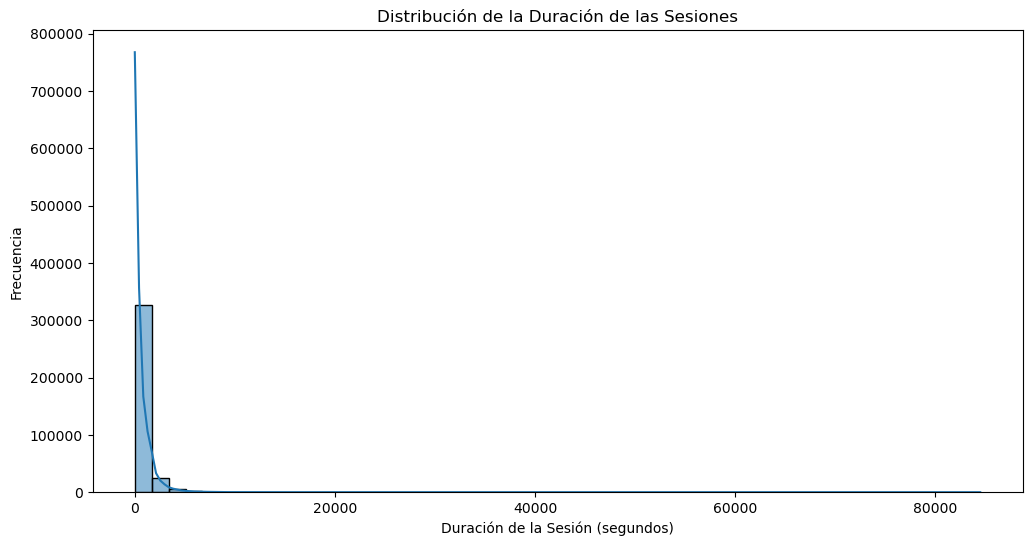

In [19]:
import seaborn as sns

# Graficar la duración de las sesiones
plt.figure(figsize=(12, 6))
sns.histplot(df_visits['duracion_sesion_seg'], bins=50, kde=True)

# Configuración del gráfico
plt.title('Distribución de la Duración de las Sesiones')
plt.xlabel('Duración de la Sesión (segundos)')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

In [20]:
# Crear una tabla con las primeras filas de duración de las sesiones
tabla_duracion = df_visits[['sesion_fecha', 'uid', 'duracion_sesion_seg']]

# Mostrar la tabla
print(tabla_duracion.head())

  sesion_fecha                   uid  duracion_sesion_seg
0   2017-12-20  16879256277535980062                 1080
1   2018-02-19    104060357244891740                 1680
2   2017-07-01   7459035603376831527                    0
3   2018-05-20  16174680259334210214                 1440
4   2017-12-27   9969694820036681168                    0


**Duraciones bajas:**

En el ejemplo de la tabla, algunos valores de duracion_sesion_seg son bastante bajos (por ejemplo, 0 segundos). Esto podría indicar:

- Sesiones interrumpidas o sesiones de prueba donde el usuario no interactuó de manera significativa.

- Posibles errores en la recopilación de datos o registros de sesiones de usuarios que duraron muy poco tiempo (como abrir la página por error y cerrarla de inmediato).

**Duraciones moderadas:**

Valores de duración como 1080 segundos (18 minutos) y 1680 segundos (28 minutos) son más representativos de una interacción estándar en la página, lo que podría indicar sesiones de usuarios que pasaron un tiempo adecuado navegando o realizando actividades en la plataforma.

**Duraciones altas:**

Un valor de 1440 segundos (24 minutos) también es común y muestra que los usuarios estuvieron interactuando con la página durante un periodo considerable.

Sin embargo, las duraciones extremadamente largas (por ejemplo, varias horas) podrían ser el resultado de sesiones prolongadas, aunque esto puede variar dependiendo de las características de la plataforma y el tipo de interacción esperada.

**Gráfico de Distribución:**

Muestra una distribución sesgada hacia la izquierda (con la mayoría de las sesiones teniendo una duración baja). Esto es común en muchas plataformas donde la mayoría de los usuarios navegan por períodos relativamente cortos, pero algunos usuarios permanecen mucho más tiempo en la plataforma.

Se observa que la frecuencia de sesiones con baja duración es mucho más alta, lo que significa que muchas sesiones son breves. Esto puede ser indicativo de interacciones rápidas o cierres prematuros.

---

## A.4) ¿Con qué frecuencia los usuarios regresan?

Aquí vamos a analizar la frecuencia con la que los usuarios regresan al sitio web. Para esto, vamos a calcular la diferencia de tiempo entre cada visita de un usuario y su visita inmediatamente anterior.

In [21]:
# Ordenar el DataFrame por Uid y Start_Ts
visits_dif = df_visits.sort_values(['uid', 'start_ts']).copy()

In [22]:
# Agrupar por Uid y calcular la diferencia entre el tiempo de inicio de sesiones consecutivas
visits_dif['time_since_last_visit'] = visits_dif.groupby('uid')['start_ts'].diff()
# 'time_since_last_visit' ahora contiene la diferencia de tiempo entre la sesión actual
# y la sesión anterior para cada usuario. La primera sesión de cada usuario tendrá un valor NaT.

In [23]:
visits_dif['days_since_last_visit'] = visits_dif['time_since_last_visit'].dt.days

In [24]:
print("\nEstadísticas descriptivas de los días entre visitas:")
print(visits_dif['days_since_last_visit'].describe())


Estadísticas descriptivas de los días entre visitas:
count    131231.000000
mean         27.676837
std          49.693727
min           0.000000
25%           0.000000
50%           4.000000
75%          31.000000
max         362.000000
Name: days_since_last_visit, dtype: float64


In [25]:
# La distribución de los intervalos de tiempo:
print("\nDistribución de los intervalos de tiempo (en días):")
print(visits_dif['days_since_last_visit'].value_counts().sort_index())


Distribución de los intervalos de tiempo (en días):
days_since_last_visit
0.0      41443
1.0      10174
2.0       6298
3.0       4663
4.0       3596
         ...  
358.0        2
359.0        1
360.0        1
361.0        1
362.0        1
Name: count, Length: 363, dtype: int64


In [26]:
# Categorizar la frecuencia
bins = [0, 1, 7, 30, 90, 365, float('inf')]
labels = ['Mismo día', 'Dentro de la semana', 'Dentro del mes', 'Dentro de 3 meses', 'Dentro del año', 'Más de un año']
visits_dif['return_frequency_category'] = pd.cut(visits_dif['days_since_last_visit'], bins=bins, labels=labels, right=False)

print("\nCategorías de frecuencia de regreso:")
print(visits_dif['return_frequency_category'].value_counts().sort_index())


Categorías de frecuencia de regreso:
return_frequency_category
Mismo día              41443
Dentro de la semana    30327
Dentro del mes         25539
Dentro de 3 meses      20409
Dentro del año         13513
Más de un año              0
Name: count, dtype: int64


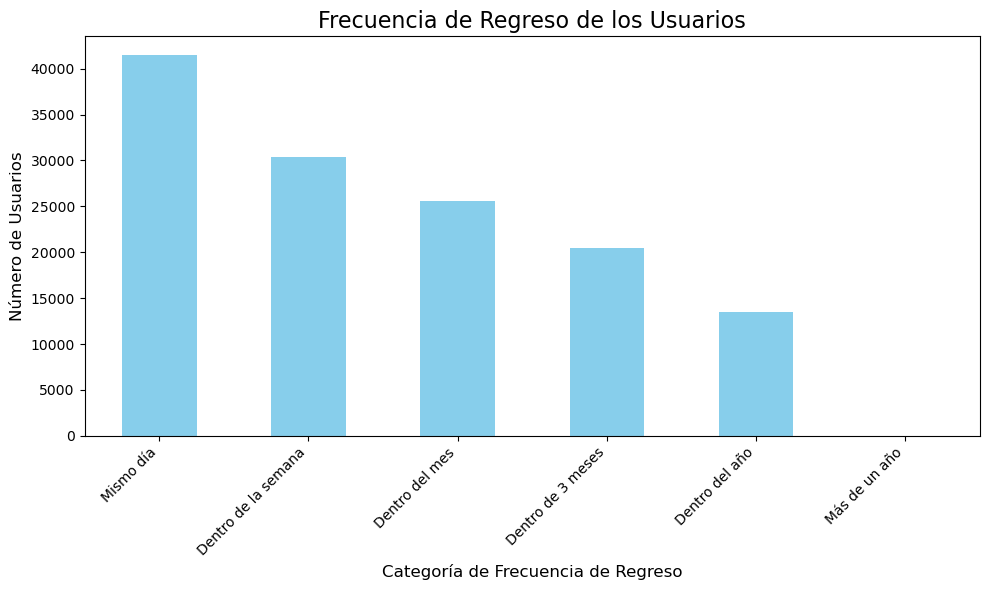

In [27]:
category_counts = visits_dif['return_frequency_category'].value_counts().sort_index()

# Crea el barchart para ver la frecuencia de distribucion 
plt.figure(figsize=(10,6))
category_counts.plot(kind='bar', color='skyblue')

# Agrega titulos y etiquetas 
plt.title('Frecuencia de Regreso de los Usuarios', fontsize=16)
plt.xlabel('Categoría de Frecuencia de Regreso', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)

# Display plot
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Distribución de los Intervalos de Tiempo (días desde la última visita)**

El valor más frecuente es 0 días, lo que indica que más de 40,000 visitas fueron realizadas por usuarios que regresaron el mismo día. Esto sugiere una alta tasa de interacción inmediata de los usuarios, lo cual podría ser indicativo de una plataforma con interacciones recurrentes, como redes sociales o servicios que requieren revisitas frecuentes.

- Dentro de la semana (1-7 días): Más de 10,000 usuarios regresan dentro de la misma semana, lo que indica una retención de usuarios dentro del corto plazo.

- Dentro del mes (1-30 días): Más de 25,000 usuarios regresan dentro de un mes, lo que sigue sugiriendo una buena tasa de retención en plazos mensuales.

A medida que el tiempo entre visitas aumenta, los números de usuarios que regresan disminuyen, lo que es esperado. Por ejemplo, más de 20,000 usuarios regresan dentro de tres meses, y solo 13,500 usuarios regresan dentro de un año.

**Gráfico de Frecuencia de Regreso de los Usuarios**

El gráfico de barras muestra claramente la distribución de las categorías de frecuencia de regreso de los usuarios:

- La categoría de "Mismo día" tiene el mayor número de usuarios, lo que refuerza la idea de que muchos usuarios regresan casi de inmediato a la plataforma.

- La categoría "Más de un año" tiene cero usuarios, lo que indica que todos los usuarios que regresan lo hacen dentro de un año, lo cual es positivo, pero también puede sugerir que la plataforma no tiene una base de usuarios que se olvida por más de un año. Es una buena señal de retención, aunque también puede implicar que los usuarios no están comprometidos a largo plazo.

---

# B. Ventas

En esta sección, vamos a analizar las métricas clave de las **ventas**:
1. **¿Cuándo empieza la gente a comprar?** - Calcularemos el tiempo que transcurre entre el **registro** del usuario (primera sesión) y su primera compra.
2. **¿Cuántos pedidos hacen durante un período de tiempo dado?** - Veremos la cantidad de pedidos realizados en un intervalo de tiempo específico.
3. **¿Cuál es el tamaño promedio de compra?** - Calcularemos el **ticket promedio** de compra.
4. **¿Cuánto dinero traen?** - Calcularemos el **Lifetime Value (LTV)** por cohorte de usuarios.

## B.1) ¿Cuándo empieza la gente a comprar?

Para esta sección, calcularemos el **tiempo entre la primera sesión** (registro) y la **primera compra** de un usuario. Esto nos ayudará a clasificar a los usuarios en diferentes categorías de conversión (por ejemplo, **Conversion 0d**, **Conversion 1d**, etc.).

In [28]:
# Calcular la primera sesión de cada usuario
primeras_sesiones = df_visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()

# Renombramos la columna 
primeras_sesiones.rename(columns={'start_ts': 'fecha_primera_sesion'}, inplace=True)

# Primero, aseguramos que tenemos la fecha de la primera compra de cada usuario
primeras_compras = df_orders.groupby('uid').agg({'buy_ts': 'min'}).reset_index()

# Unir la información de la primera compra con el DataFrame de visitas (primeras sesiones)
df_compras = pd.merge(primeras_compras, primeras_sesiones, on='uid', how='inner')

# Calcular el tiempo entre la primera sesión y la primera compra
df_compras['dias_hasta_compra'] = (df_compras['buy_ts'] - df_compras['fecha_primera_sesion']).dt.days

# Clasificar a los usuarios según el tiempo hasta la primera compra (Conversion 0d, 1d, etc.)
df_compras['conversion'] = pd.cut(df_compras['dias_hasta_compra'], bins=[-1, 0, 1, 7, 30, 365, float('inf')],
                                  labels=['Conversion 0d', 'Conversion 1d', 'Conversion 1w', 'Conversion 1m', 'Conversion 1y', 'Conversion >1y'])

# Verificar las primeras filas
df_compras.head()

,uid,buy_ts,fecha_primera_sesion,dias_hasta_compra,conversion
0,313578113262317,2018-01-03 21:51:00,2017-09-18 22:49:00,106,Conversion 1y
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0,Conversion 0d
2,2429014661409475,2017-10-11 18:33:00,2017-10-11 17:14:00,0,Conversion 0d
3,2464366381792757,2018-01-28 15:54:00,2018-01-27 20:10:00,0,Conversion 0d
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0,Conversion 0d


/var/folders/ws/xnp5l9k56zggyb_d7zfv75rm0000gn/T/ipykernel_4092/2917090377.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_counts.index, y=conversion_counts.values, palette='viridis')


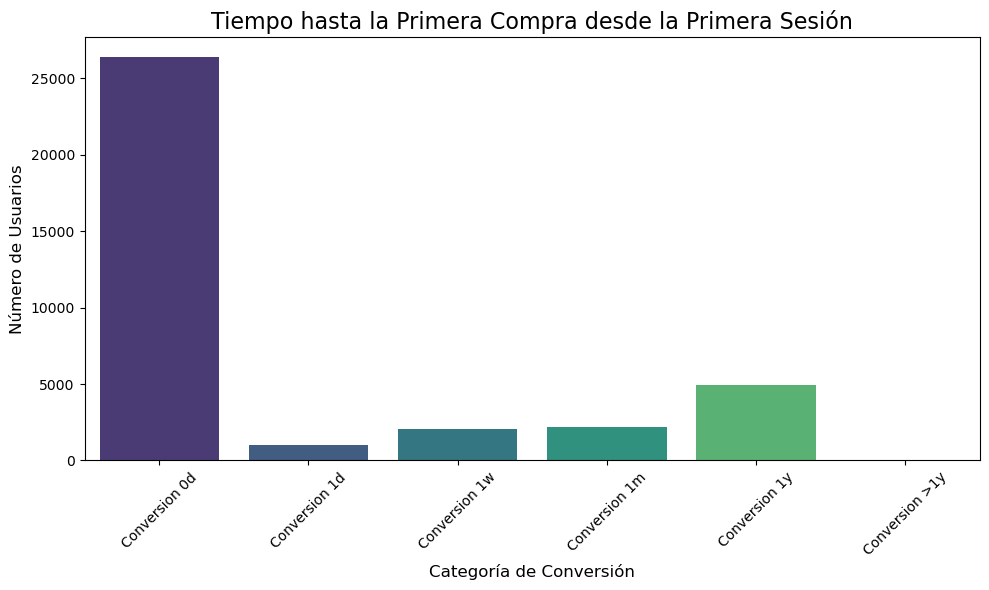

In [29]:
# Count the occurrences of each 'conversion' category
conversion_counts = df_compras['conversion'].value_counts().sort_index()

# Create a bar plot to visualize the time between the first session and first purchase
plt.figure(figsize=(10,6))
sns.barplot(x=conversion_counts.index, y=conversion_counts.values, palette='viridis')

# Add titles and labels
plt.title('Tiempo hasta la Primera Compra desde la Primera Sesión', fontsize=16)
plt.xlabel('Categoría de Conversión', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribución de la Conversión:**

La mayoría de los usuarios realizan su primera compra el mismo día en que se registran (aproximadamente 25,000 usuarios). Esto indica una tasa de conversión inmediata alta, lo que podría reflejar una plataforma donde los usuarios encuentran rápidamente lo que buscan o toman decisiones de compra rápidas.

Una pequeña cantidad de usuarios realiza su compra en el día siguiente o dentro de una semana o mes. Esto sugiere que hay una fracción de usuarios que, aunque muestran interés inmediatamente, toman algo de tiempo para decidir realizar la compra.

Solo algunos usuarios tardan un año en realizar su compra. Aunque este grupo es pequeño, puede ser significativo para identificar patrones de usuarios indecisos o los que requieren más tiempo para tomar una decisión de compra.

**Gráfico de Frecuencia de Conversiones:**

El gráfico muestra la frecuencia de las conversiones en diferentes categorías (0d, 1d, 1w, 1m, 1y, >1y). Se observa que la gran mayoría de las conversiones ocurren dentro del primer día (Conversión 0d), lo que sugiere que los usuarios que tienen una intención de compra clara, la completan rápidamente. La caída dramática en las conversiones de 1 día a 1 semana indica que la mayoría de los usuarios no necesitan mucho tiempo para tomar su decisión de compra, pero algunos usuarios tardan más en volver a realizar la compra.

---

## B.2) ¿Cuántos pedidos hacen durante un período de tiempo dado?

En esta sección, vamos a contar cuántos pedidos realiza cada usuario dentro de un intervalo de tiempo específico. Esto nos ayudará a entender el comportamiento de compra de los usuarios a lo largo del tiempo.


In [30]:
# Contamos cuántos pedidos se hicieron por usuario durante un mes específico
pedidos_por_mes = df_orders.groupby([df_orders['buy_ts'].dt.to_period('M'), 'uid']).size().reset_index(name='n_pedidos')

# Mostrar las primeras filas para verificar
pedidos_por_mes.head()

,buy_ts,uid,n_pedidos
0,2017-06,1575281904278712,2
1,2017-06,16233238570251706,1
2,2017-06,29085576454138824,1
3,2017-06,31782048561502182,1
4,2017-06,50884319066603964,1


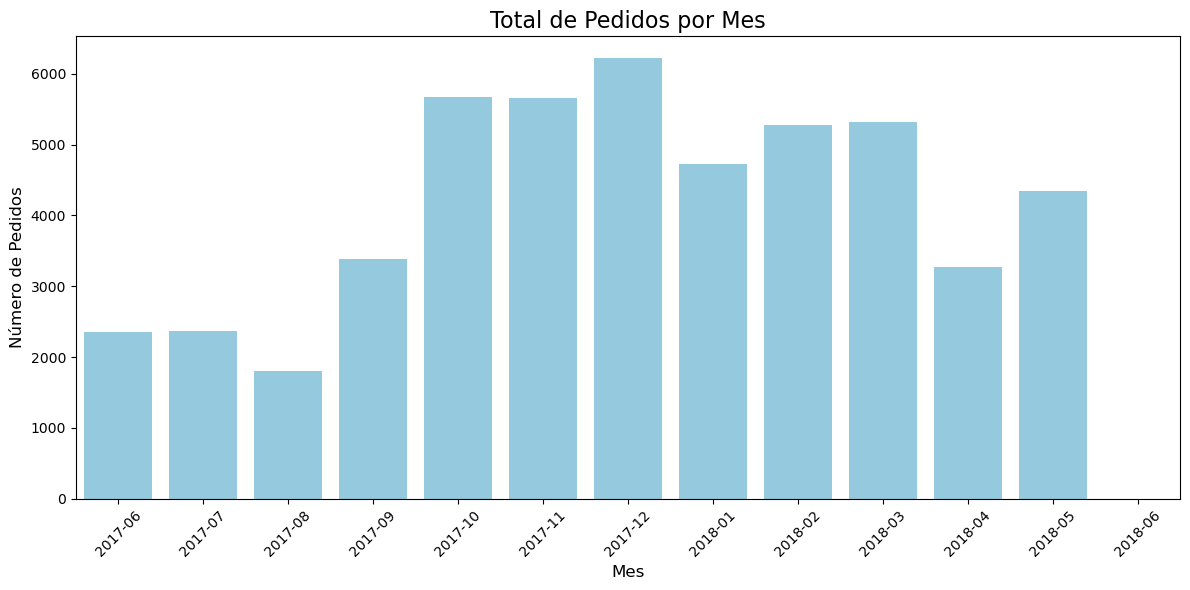

In [31]:
# Agrupar los pedidos por mes para obtener el total de pedidos por mes
pedidos_totales_por_mes = pedidos_por_mes.groupby('buy_ts')['n_pedidos'].sum().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=pedidos_totales_por_mes, x='buy_ts', y='n_pedidos', color='skyblue')

# Añadir título y etiquetas
plt.title('Total de Pedidos por Mes', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)

# Mejorar el formato de las etiquetas en el eje x
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Número de pedidos por mes:**

El gráfico muestra el número total de pedidos por mes. Se observa un aumento progresivo en el número de pedidos desde junio de 2017 hasta diciembre de 2017, con un pico máximo en diciembre de 2017, que podría estar relacionado con promociones de fin de año o campañas de marketing. Después de diciembre, hay una ligera disminución en los pedidos, con un ligero repunte en mayo de 2018.

**Tendencia de crecimiento:**

En general, el número de pedidos tiende a crecer desde los primeros meses de 2017 hasta llegar a un nivel más estable en 2018.

---

## B.3) ¿Cuál es el tamaño promedio de compra?

En esta sección, calcularemos el **ticket promedio**, que es el valor promedio de las compras realizadas por cada usuario.

In [32]:
# Calcular el tamaño promedio de compra 
ticket_promedio = df_orders.groupby('uid').agg({'revenue': 'mean'}).reset_index()

# Verificar las primeras filas
ticket_promedio.head()

,uid,revenue
0,313578113262317,0.550
1,1575281904278712,1.525
2,2429014661409475,73.330
3,2464366381792757,2.440
4,2551852515556206,5.495


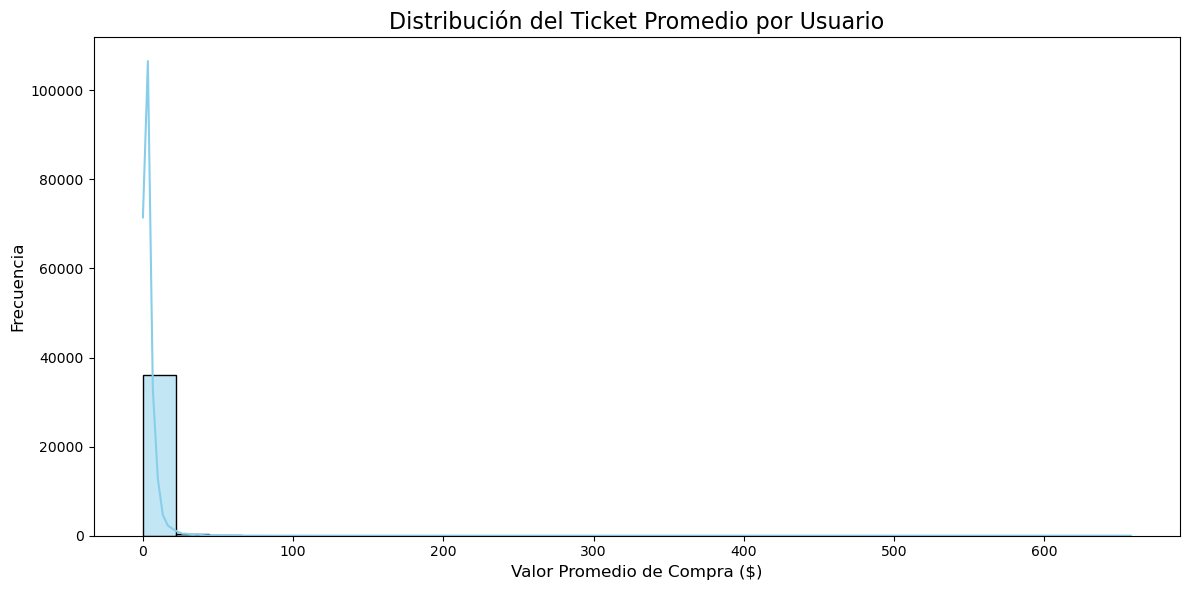

In [33]:
# Graficar el ticket promedio
plt.figure(figsize=(12, 6))
sns.histplot(ticket_promedio['revenue'], bins=30, kde=True, color='skyblue')

# Añadir título y etiquetas
plt.title('Distribución del Ticket Promedio por Usuario', fontsize=16)
plt.xlabel('Valor Promedio de Compra ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

**Distribución del Ticket Promedio:**

El gráfico muestra una distribución sesgada hacia la izquierda, con la mayoría de los usuarios realizando compras pequeñas (cerca de $0 a $10). La mayoría de los valores de ticket promedio están concentrados en un rango bajo, con algunos picos atípicos a valores más altos.

**Tamaño promedio de compra:**

El valor más común se encuentra cerca de $0 a $10, indicando que muchas transacciones en la plataforma son pequeñas. Existen algunos outliers (valores muy altos), como compras por encima de $100, pero representan una pequeña fracción de los usuarios.

---

## B.4) ¿Cuánto dinero traen? (Lifetime Value - LTV por cohorte)

Finalmente, vamos a calcular el **Lifetime Value (LTV)** por cohorte. El LTV es una métrica clave que nos indica cuánto valor genera un usuario a lo largo de su vida como cliente.

In [34]:
# Definir Cohortes (basado en la primera compra)
first_purchase_date = df_orders.groupby('uid')['buy_ts'].min().reset_index()
first_purchase_date['cohort_month'] = first_purchase_date['buy_ts'].dt.to_period('M')

In [35]:
# Combinar la información de la cohorte con la tabla de órdenes
df_orders_merged = pd.merge(df_orders, first_purchase_date[['uid', 'cohort_month']], on='uid')

In [36]:
df_orders_merged

,buy_ts,revenue,uid,cohort_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06
...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05


In [37]:
# Calcular el período relativo de cada orden dentro de la cohorte
df_orders_merged['order_month'] = df_orders_merged['buy_ts'].dt.to_period('M')
df_orders_merged['period_number'] = (df_orders_merged['order_month'] - df_orders_merged['cohort_month']).apply(lambda x: x.n)

In [38]:
# Calcular los Ingresos por Cohorte a lo Largo del Tiempo
cohort_revenue = df_orders_merged.groupby(['cohort_month', 'period_number'])['revenue'].sum().reset_index()

In [39]:
# Calcular el LTV Promedio por Usuario en Cada Cohorte
# Contar el número de usuarios únicos en cada cohorte
cohort_size = df_orders_merged.groupby('cohort_month')['uid'].nunique().reset_index()
cohort_revenue = pd.merge(cohort_revenue, cohort_size, on='cohort_month')
cohort_revenue['ltv'] = cohort_revenue['revenue'] / cohort_revenue['uid']

# Pivotear la tabla para una mejor visualización del LTV por cohorte a lo largo del tiempo
ltv_pivot = cohort_revenue.pivot_table(index='cohort_month', columns='period_number', values='ltv')

print("LTV por Cohorte:")
ltv_pivot

LTV por Cohorte:


period_number,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2017-06,4.724414,0.485329,0.437637,0.954671,1.022531,0.735502,0.950440,0.581592,0.553213,0.605788,0.571261,0.256856
2017-07,6.010218,0.335211,0.623531,0.358976,0.176791,0.156048,0.120208,0.141820,0.161232,0.147145,0.155673,NaN
2017-08,5.276518,0.471993,0.458482,0.391277,0.494051,0.283540,0.210664,0.405007,0.292212,0.187978,NaN,NaN
2017-09,5.644529,1.117586,0.520930,3.975792,0.400558,0.647067,0.701608,0.243150,0.184006,NaN,NaN,NaN
2017-10,5.003733,0.535763,0.191394,0.157145,0.151560,0.120362,0.084816,0.115470,NaN,NaN,NaN,NaN
2017-11,5.154683,0.399233,0.199556,0.324952,0.148013,0.053879,0.114928,NaN,NaN,NaN,NaN,NaN
2017-12,4.738191,0.260374,0.925097,1.065275,0.312930,0.338047,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,4.135636,0.294758,0.304281,0.142778,0.062698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4.156987,0.278274,0.078515,0.074144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


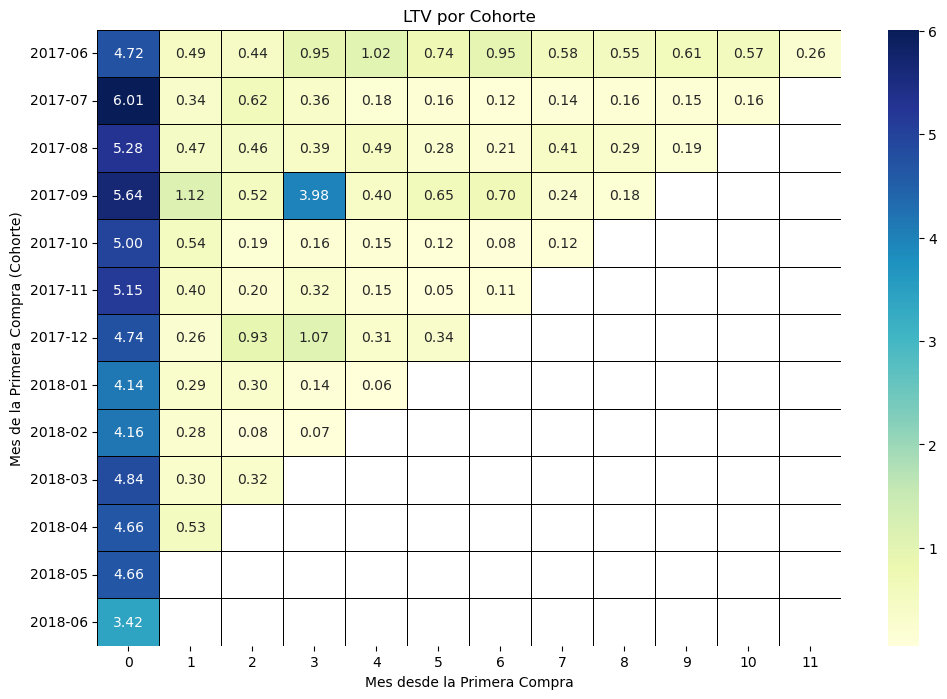

In [40]:
# Visualizar la evolución del LTV por cohorte
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(ltv_pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, linecolor='black')
plt.title('LTV por Cohorte')
plt.xlabel('Mes desde la Primera Compra')
plt.ylabel('Mes de la Primera Compra (Cohorte)')
plt.show()

**Distribución del LTV por cohorte:**

En el gráfico de LTV por cohorte, se observa que las cohortes de 2017-06 y 2017-07 tienen un LTV más alto en los primeros meses (0, 1, 2, 3). Esto sugiere que los usuarios de esas cohortes generaron más ingresos rápidamente. Las cohortes más recientes como 2018-05 y 2018-06 muestran valores de LTV más bajos en sus primeros meses, lo que puede indicar que los usuarios de esas cohortes tienen un comportamiento de compra más lento o menos frecuente.

**Tendencia:**

El LTV disminuye a medida que las cohortes se alejan de su mes de primera compra, lo que sugiere que los usuarios más recientes tienen menos valor en el largo plazo en comparación con los usuarios antiguos.

---

# C. Marketing

En esta sección, vamos a analizar las métricas clave relacionadas con el marketing:

1. **Gastos totales y por fuente a lo largo del tiempo**: Vamos a analizar cómo evolucionan los gastos totales y los gastos por fuente de marketing durante el tiempo.
2. **¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes? (CAC por fuente)**: Calcularemos el **Customer Acquisition Cost (CAC)** por fuente.
3. **¿Cuán rentables eran las inversiones? (ROMI temporal y por fuente)**: Evaluaremos la **rentabilidad de las inversiones en marketing** usando el **Return on Marketing Investment (ROMI)**.

## C.1) Gastos totales y por fuente a lo largo del tiempo

En esta sección, vamos a analizar los **gastos totales** y los **gastos por fuente** a lo largo del tiempo para entender cómo se distribuyen y evolucionan a lo largo de los meses.

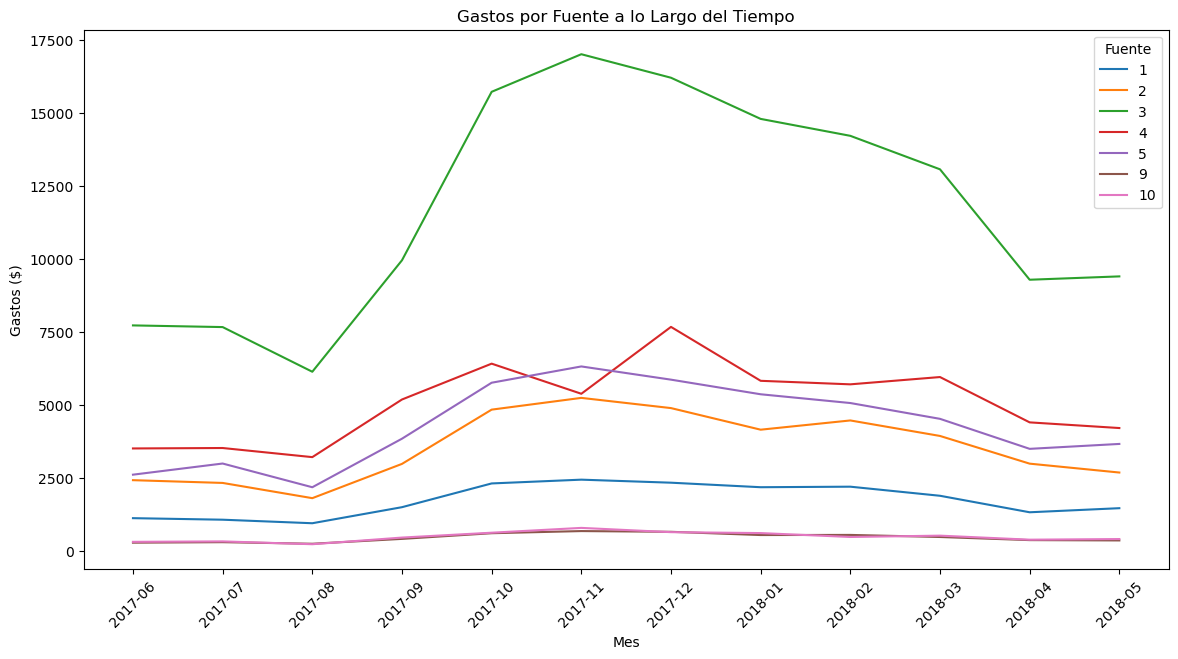

In [41]:
# Aseguramos que la columna 'dt' está en formato datetime
df_costs['dt'] = pd.to_datetime(df_costs['dt'])

# Convertimos 'dt' a periodo mensual
df_costs['mes'] = df_costs['dt'].dt.to_period('M')

# Agrupamos los gastos por mes y fuente (source_id)
gastos_por_mes_fuente = df_costs.groupby(['mes', 'source_id']).agg({'costs': 'sum'}).reset_index()

# Graficamos los resultados de los gastos por fuente
import matplotlib.pyplot as plt

# Crear gráfico para mostrar gastos por fuente
fig, ax = plt.subplots(figsize=(14, 7))
for fuente in gastos_por_mes_fuente['source_id'].unique():
    fuente_data = gastos_por_mes_fuente[gastos_por_mes_fuente['source_id'] == fuente]
    ax.plot(fuente_data['mes'].astype(str), fuente_data['costs'], label=fuente)

ax.set_title('Gastos por Fuente a lo Largo del Tiempo')
ax.set_xlabel('Mes')
ax.set_ylabel('Gastos ($)')
ax.legend(title='Fuente')
plt.xticks(rotation=45)
plt.show()

Fuente 3 (color verde) muestra un aumento significativo en los gastos, destacándose especialmente en diciembre de 2017. Este comportamiento podría reflejar una campaña o evento relevante que impulsó los gastos.

Fuente 1 (color azul) tiene un crecimiento constante pero más moderado. A partir de finales de 2017, los gastos siguen una tendencia estable.

Fuente 4 (color naranja) también experimenta un aumento en los gastos en algunos meses, pero sus cifras no son tan altas como las de Fuente 3.

Fuentes 5, 9 y 10 (colores púrpura, marrón y rosa) tienen un gasto más bajo comparado con las otras fuentes, con leves aumentos a lo largo del tiempo.

---

## C.2) ¿Cuál fue el Costo de Adquisición de Clientes de cada una de las Fuentes? (CAC por fuente)

El **Customer Acquisition Cost (CAC)** se calcula como el **total de los costos de marketing de cada mes** dividido por el **número de compradores en cada mes**. 
Vamos a calcular el CAC de cada fuente utilizando la siguiente fórmula:

$$
 \text{CAC} = \frac{\text{Total de los Costos}}{\text{Número de Compradores}}
$$

Para calcular el **número de compradores** por cada fuente y mes, agrupamos los datos de las órdenes (`df_orders`) por mes y fuente. Luego, unimos esos datos con los gastos totales por mes y fuente para calcular el **CAC**.

In [42]:
# Hacemos un merge entre df_orders y df_visits utilizando 'uid' como clave
df_orders = pd.merge(df_orders, df_visits[['uid', 'source_id']], on='uid', how='left')

# Convertimos 'buy_ts' a periodo mensual
df_orders['mes'] = df_orders['buy_ts'].dt.to_period('M')

# Contamos el número de compradores únicos por fuente y mes
compradores_por_fuente_mes = df_orders.groupby(['source_id', 'mes'])['uid'].nunique().reset_index(name='num_compradores')

# Ahora, unimos los datos de gastos con el número de nuevos clientes por fuente
gastos_y_compradores = pd.merge(gastos_por_mes_fuente, compradores_por_fuente_mes, left_on=['source_id', 'mes'], right_on=['source_id', 'mes'], how='left')

# Calculamos el CAC por fuente
gastos_y_compradores['cac'] = gastos_y_compradores['costs'] / gastos_y_compradores['num_compradores']

# Mostrar los resultados
print(gastos_y_compradores[['source_id', 'mes', 'costs', 'num_compradores', 'cac']])


    source_id      mes    costs  num_compradores       cac
0           1  2017-06  1125.61              401  2.807007
1           2  2017-06  2427.38              457  5.311554
2           3  2017-06  7731.65              874  8.846281
3           4  2017-06  3514.80              644  5.457764
4           5  2017-06  2616.12              571  4.581646
..        ...      ...      ...              ...       ...
79          3  2018-05  9411.42             1323  7.113696
80          4  2018-05  4214.21             1307  3.224338
81          5  2018-05  3669.56              956  3.838452
82          9  2018-05   362.17              182  1.989945
83         10  2018-05   409.86              203  2.019015

[84 rows x 5 columns]


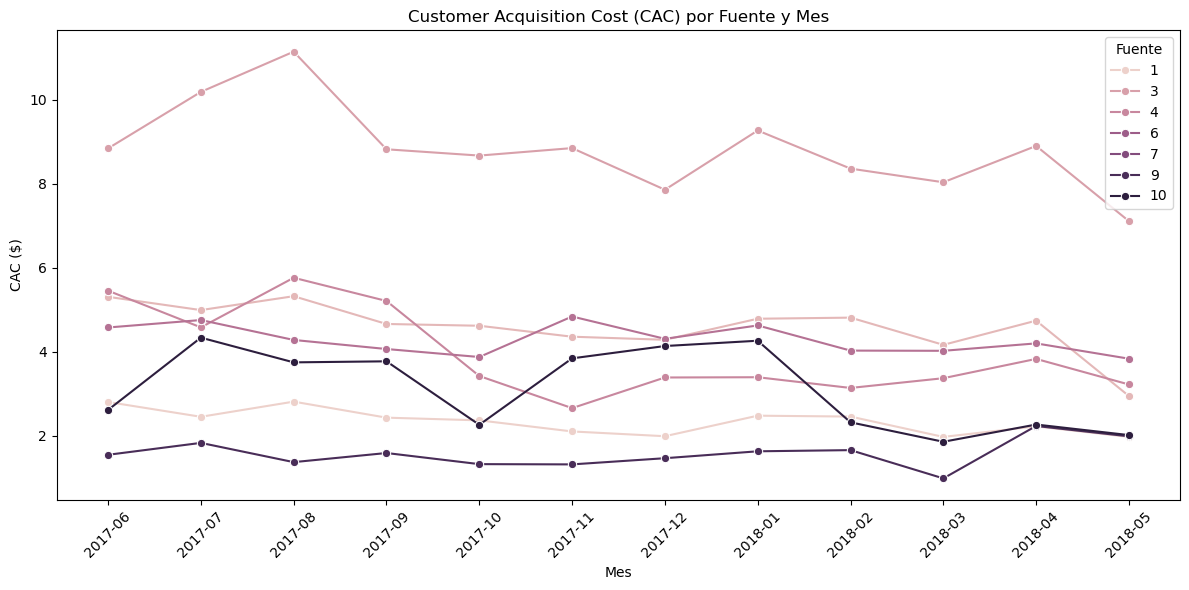

In [43]:
# Convertir 'mes' a string para que sea tratada como una categoría en la gráfica
gastos_y_compradores['mes'] = gastos_y_compradores['mes'].astype(str)

# Crear la gráfica del CAC por fuente y mes
plt.figure(figsize=(12, 6))
sns.lineplot(data=gastos_y_compradores, x='mes', y='cac', hue='source_id', marker='o')

# Configuración del gráfico
plt.title('Customer Acquisition Cost (CAC) por Fuente y Mes')
plt.xlabel('Mes')
plt.ylabel('CAC ($)')
plt.xticks(rotation=45)  # Rotar las etiquetas de los meses para que se vean mejor
plt.legend(title='Fuente')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Fuente 1 (en azul) muestra un comportamiento relativamente estable con un costo de adquisición que se mantiene alrededor de 3 a 6 dólares.

Fuente 3 (en rosa claro) tiene picos notables de CAC, especialmente a finales de 2017 y principios de 2018, lo que indica que la adquisición de clientes fue más costosa durante esos meses.

Fuente 4 (en verde) tiene una tendencia similar, pero presenta un descenso en los meses más recientes.

Fuentes 9 y 10 (en morado y rosa oscuro) muestran un patrón descendente de CAC en los últimos meses, con picos en 2017 y disminución en 2018.

---

### C.3) ¿Cuán Rentables Eran las Inversiones? (ROMI)

El **Return on Marketing Investment (ROMI)** se calcula con la fórmula:

$$
\text{ROMI} = \frac{\text{Ingresos Generados} - \text{Costos}}{\text{Costos}}
$$

Primero, calcular los **ingresos generados** por cada fuente y mes. Luego, calculamos el **ROMI** al restar los costos de marketing de los ingresos y dividir entre los costos.

    source_id      mes       romi
0           1  2017-06  44.775135
1           2  2017-06  19.444269
2           3  2017-06  -0.034123
3           4  2017-06   2.881919
4           5  2017-06   7.947445
..        ...      ...        ...
79          3  2018-05   1.904335
80          4  2018-05   4.970633
81          5  2018-05  14.147320
82          9  2018-05   6.010906
83         10  2018-05   5.287366

[84 rows x 3 columns]


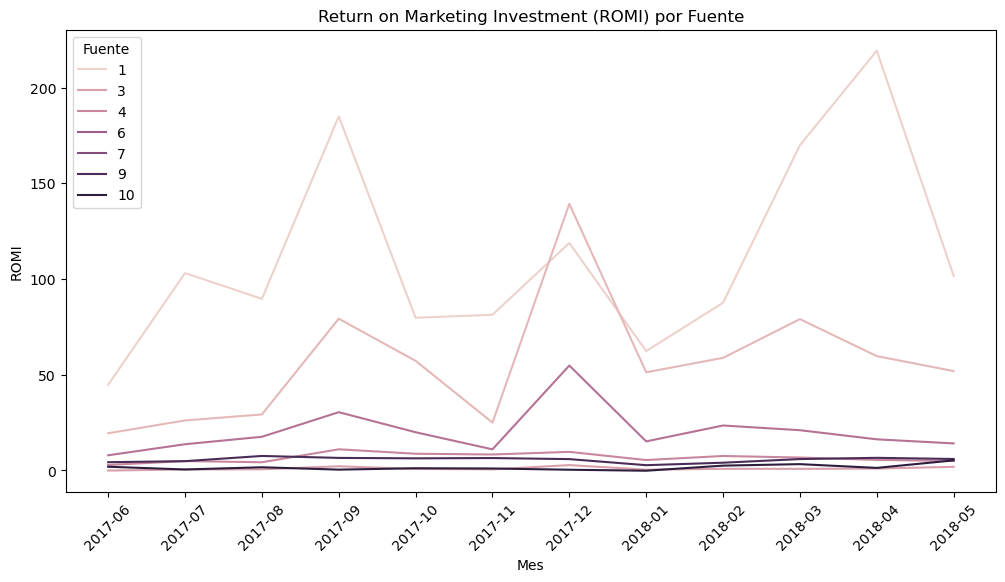

In [44]:
# Agrupar las órdenes por fuente y mes para calcular los ingresos generados
ingresos_por_fuente = df_orders.groupby(['source_id', 'mes'])['revenue'].sum().reset_index()

# Merge de los ingresos con los gastos totales
romi = pd.merge(gastos_por_mes_fuente, ingresos_por_fuente, left_on=['source_id', 'mes'], right_on=['source_id', 'mes'], how='left')

# Calcular el ROMI
romi['romi'] = (romi['revenue'] - romi['costs']) / romi['costs']

# Asegúrate de que 'mes' esté en formato adecuado (string) para el gráfico
romi['mes'] = romi['mes'].astype(str)  # Convertir 'mes' a string

# Mostrar el ROMI por fuente y mes
print(romi[['source_id', 'mes', 'romi']])

# Graficar el ROMI por fuente y mes
plt.figure(figsize=(12, 6))
sns.lineplot(data=romi, x='mes', y='romi', hue='source_id')
plt.title('Return on Marketing Investment (ROMI) por Fuente')
plt.xlabel('Mes')
plt.ylabel('ROMI')
plt.legend(title='Fuente')
plt.xticks(rotation=45)
plt.show()



El **ROMI** (Return on Marketing Investment) muestra qué tan rentable fue cada fuente de inversión a lo largo del tiempo.

En los primeros meses, especialmente en 2017-06, se observa que la Fuente 1 tuvo un ROMI muy alto, alcanzando valores de más de 40. Fuente 3 también experimentó un aumento significativo en el ROMI en 2017-09, con un pico notorio, lo que podría indicar una campaña exitosa o un evento de marketing de alto rendimiento. En 2018, la Fuente 5 y la Fuente 10 han mostrado resultados consistentes pero con valores de ROMI menores, alrededor de 2-6.

Algunas fuentes, como Fuente 3 y Fuente 9, tuvieron una caída significativa de ROMI en los meses posteriores, sugiriendo una disminución en la efectividad de sus campañas o un incremento en el costo en relación con los ingresos generados.

---

# Paso 3: Conclusiones y recomendaciones

## Conclusiones

**DAU (Usuarios Activos Diarios)**

El gráfico de **DAU** revela un comportamiento fluctuante en el tráfico diario, con un notable aumento en mayo de 2018, lo que sugiere que un evento o campaña específica atrajo un gran número de usuarios. La variabilidad diaria podría estar relacionada con campañas promocionales o fluctuaciones estacionales.

**WAU (Usuarios Activos Semanales)**

En **WAU**, las visitas semanales muestran una tendencia más estable en comparación con DAU. Aunque hay algunos picos, las fluctuaciones son menos marcadas, indicando que las visitas semanales se mantienen constantes, reflejando un buen nivel de retención en el tiempo.

**MAU (Usuarios Activos Mensuales)**

El gráfico de **MAU** muestra crecimiento durante el tercer trimestre de 2017, con un pico en septiembre. Las fluctuaciones más suaves en este gráfico proporcionan una visión más estable y a largo plazo de la actividad del sitio web, lo que es útil para evaluar el rendimiento sostenido de la plataforma.

**Número de Sesiones por Día**

La **fluctuación diaria** de sesiones resalta ciertos picos relacionados con eventos o campañas específicas. Estos picos indican que muchos usuarios realizan más de una sesión diaria, lo que contribuye al aumento de la actividad en la plataforma.

**Duración de las Sesiones**

La mayoría de las sesiones son de **corta duración**, lo que podría reflejar interacciones rápidas en la plataforma. La presencia de sesiones con duración de **0 segundos** podría indicar interacciones incompletas o errores que requieren mayor análisis.

**Frecuencia de Retorno de los Usuarios**

La **mayoría de los usuarios regresa en el mismo día**, lo que sugiere un alto nivel de **interacción inmediata**. También es notable que una cantidad significativa de usuarios regresa dentro de la semana o del mes, manteniendo el interés en la plataforma a corto plazo.

**Tiempo hasta la Primera Compra**

Muchos usuarios realizan su primera compra **el mismo día** de la sesión inicial, lo que sugiere que el proceso de compra es atractivo y directo. Sin embargo, algunos usuarios tardan más tiempo, lo que podría reflejar un ciclo de decisión más largo para ciertos productos.

**Tamaño Promedio de Compra**

El **tamaño promedio de compra** es bajo en la mayoría de los casos, pero hay una pequeña fracción de usuarios que realizan compras significativamente más grandes. Esto sugiere que la plataforma tiene una base de clientes que realiza compras más pequeñas de manera constante, mientras que una minoría realiza compras grandes.

**LTV por Cohorte**

Las cohortes más antiguas, como **2017-06**, tienen un **LTV** más alto, indicando que los usuarios de esos períodos fueron más rentables. Las cohortes más recientes, como **2018-06**, muestran un **LTV** más bajo, lo que puede sugerir menor fidelidad o efectividad de las campañas actuales.

**Fuentes de Adquisición y ROMI**

La **Fuente 3** fue la más destacada en términos de gastos, especialmente en 2017, lo que indica que fue clave para los gastos del negocio. El **ROMI** muestra fluctuaciones significativas, con algunas fuentes ofreciendo altos retornos en ciertos períodos, mientras que otras, como Fuente 5, no lograron una rentabilidad constante.

**CAC (Costo de Adquisición de Clientes)**

Algunas fuentes, como **Fuente 1**, mantienen un **CAC** relativamente estable, mientras que otras, como **Fuente 3 y 4**, experimentan variaciones. A lo largo del tiempo, algunas fuentes se han vuelto más eficientes, con una disminución en el **CAC**, mientras que otras siguen siendo costosas, especialmente en los primeros meses.

---

## Recomendación:
1. **Presupuesto**: Aumentar la inversión en **Fuente 3 y Fuente 1** por su alto rendimiento y eficiencia en **ROMI** y **CAC**.
2. **Optimización**: Evaluar el **CAC** y **ROMI** de las **Fuentes 5 y 9** para ajustar estrategias o redistribuir el presupuesto.
3. **Estrategias**: Focalizar esfuerzos en aumentar la **fidelidad** y el **LTV** de las cohortes recientes mediante **promociones dirigidas**.


---

In [45]:
import os



# %% [python]
# Guardar las nuevas columnas de df_visits
df_visits.to_csv('../data/processed/df_visits_con_nuevas_columnas.csv', index=False)

# Guardar el DataFrame de sesiones por usuario
sesiones_por_usuario.to_csv('../data/processed/sesiones_por_usuario.csv', index=True)

# Guardar el DataFrame df_compras (tiempo hasta compra y clasificación de conversión)
df_compras.to_csv('../data/processed/df_compras_conversion.csv', index=False)

# Guardar el DataFrame de pedidos por mes
pedidos_por_mes.to_csv('../data/processed/pedidos_por_mes.csv', index=False)

# Confirmar que las tablas se guardaron correctamente
print("Las tablas han sido guardadas en la carpeta 'processed'.")


Las tablas han sido guardadas en la carpeta 'processed'.


In [46]:
# Guardar el DataFrame ltv_pivot con LTV por cohorte
ltv_pivot.to_csv('../data/processed/ltv_por_cohorte.csv', index=True)

# Confirmar que el DataFrame se guardó correctamente
print("El DataFrame de LTV por Cohorte ha sido guardado en la carpeta 'processed'.")


El DataFrame de LTV por Cohorte ha sido guardado en la carpeta 'processed'.


/var/folders/ws/xnp5l9k56zggyb_d7zfv75rm0000gn/T/ipykernel_4092/3960261449.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_counts.index, y=conversion_counts.values, palette='viridis')


Todas las gráficas han sido guardadas en la carpeta '../report/figures/'


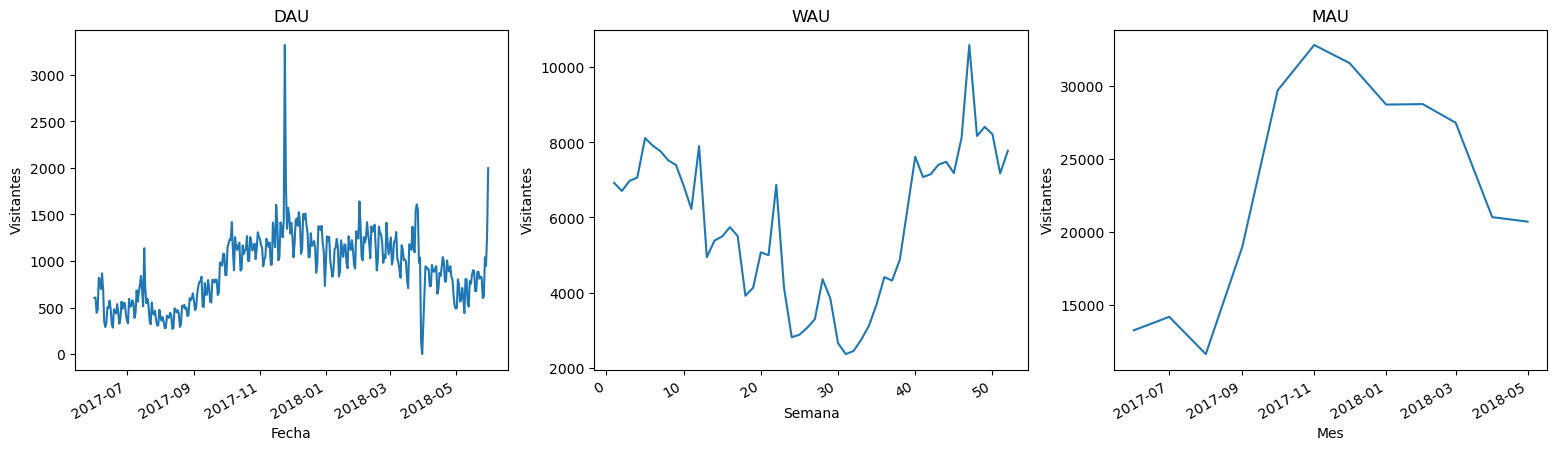

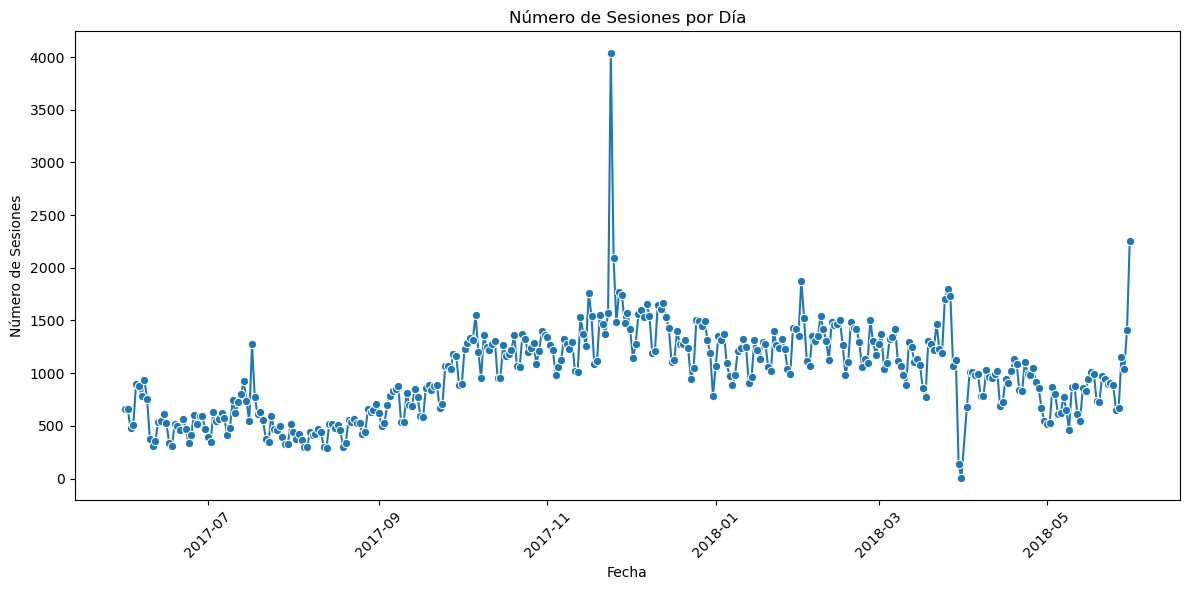

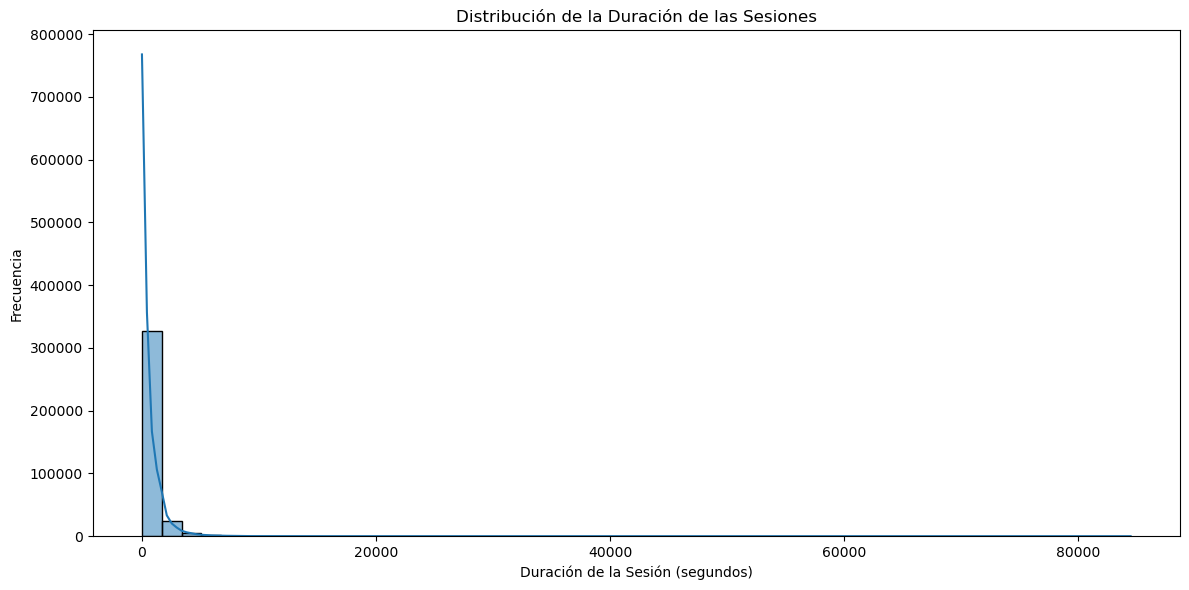

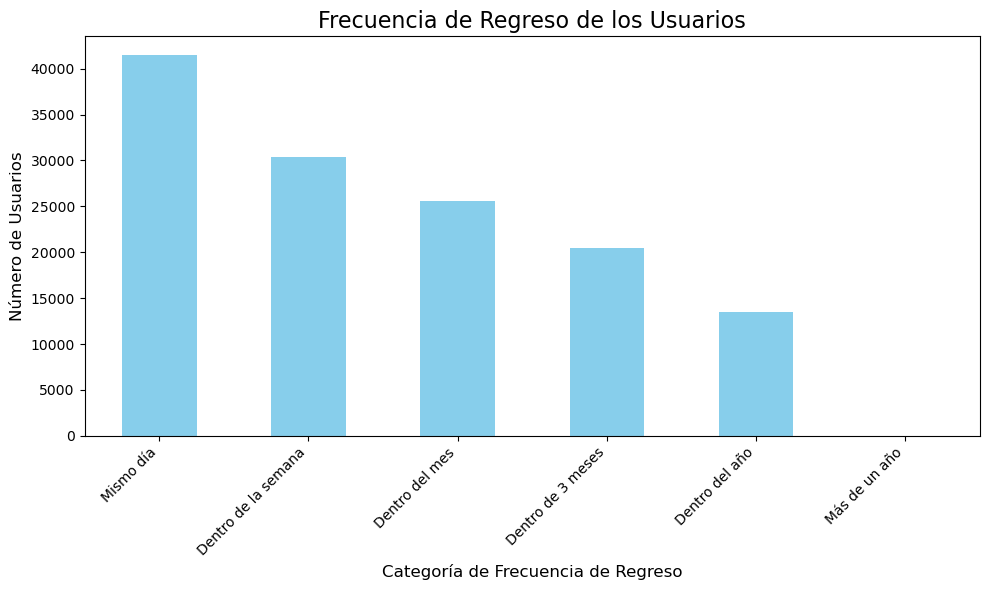

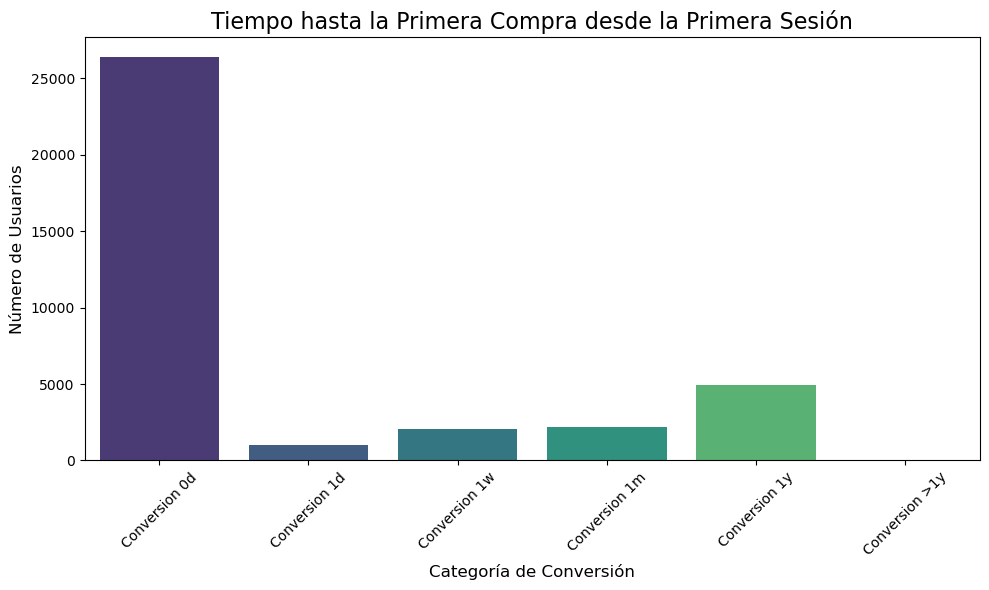

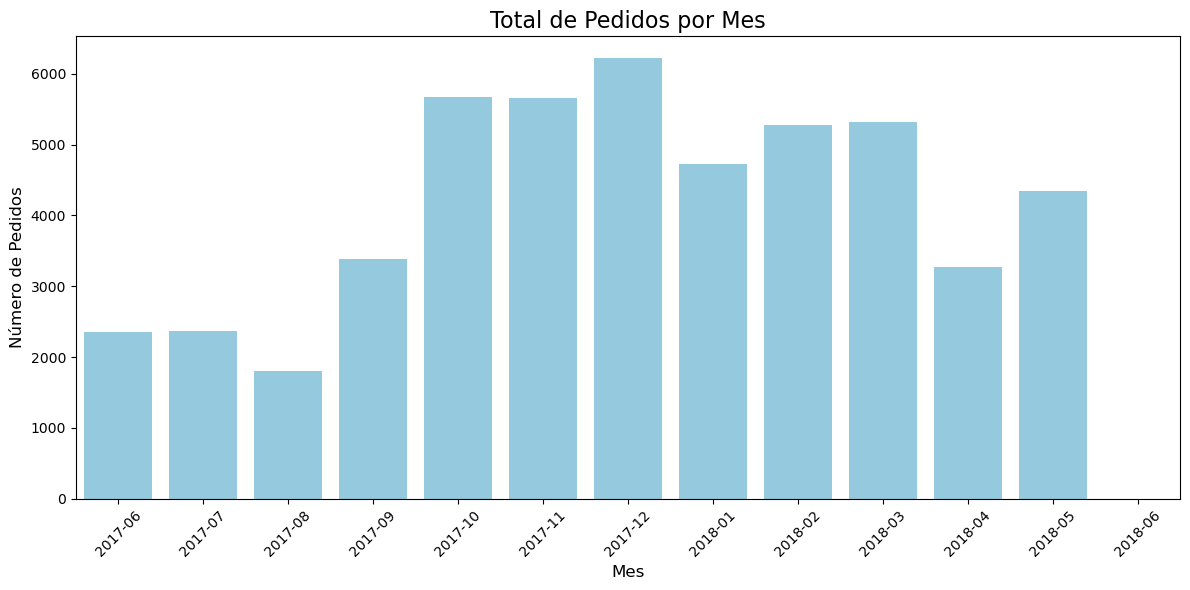

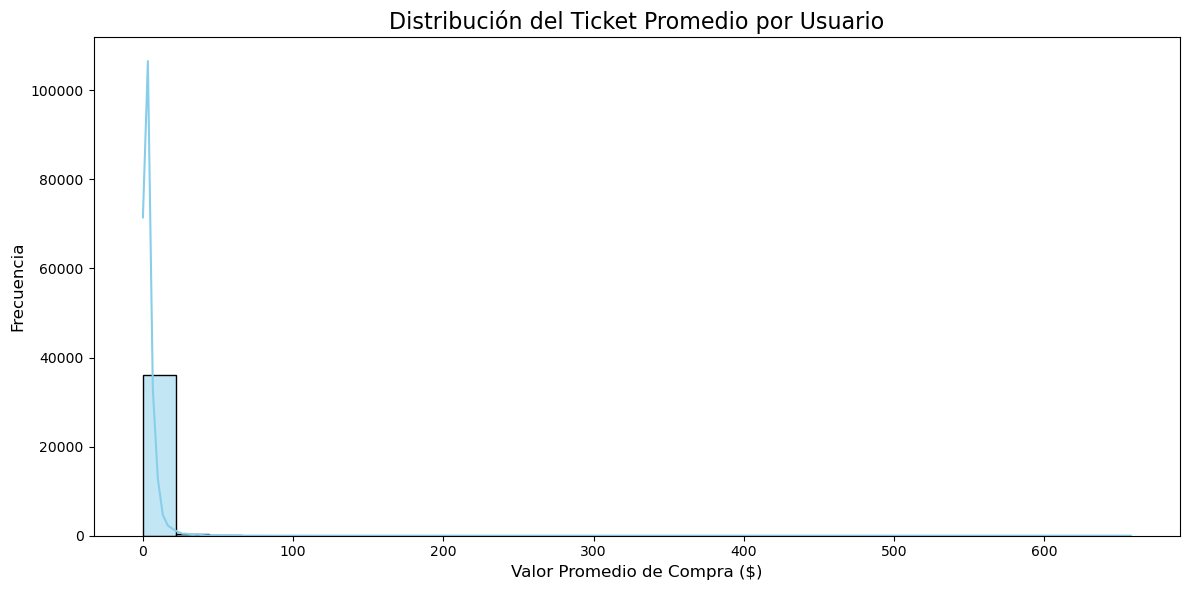

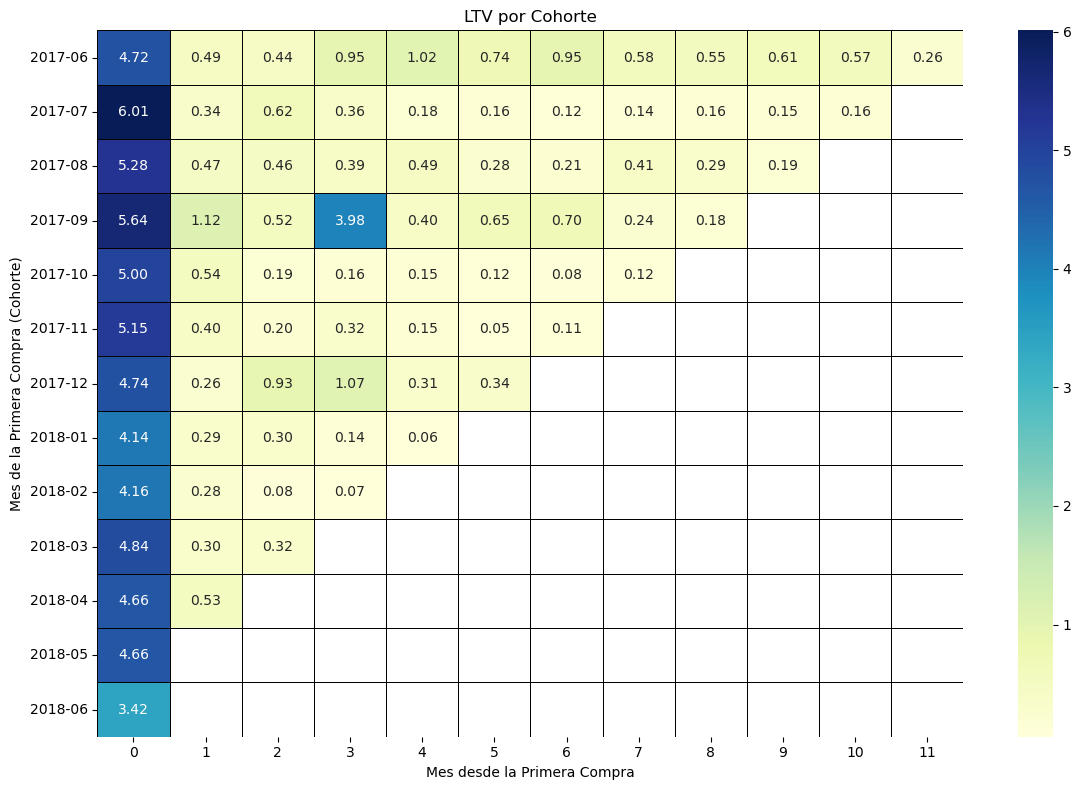

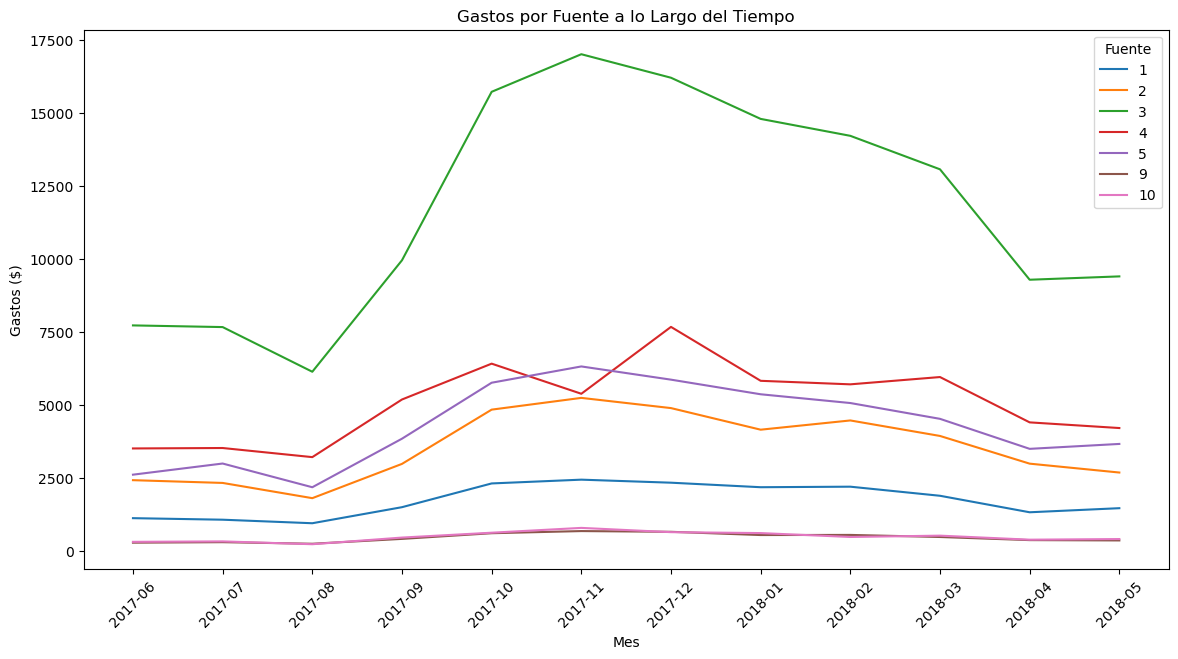

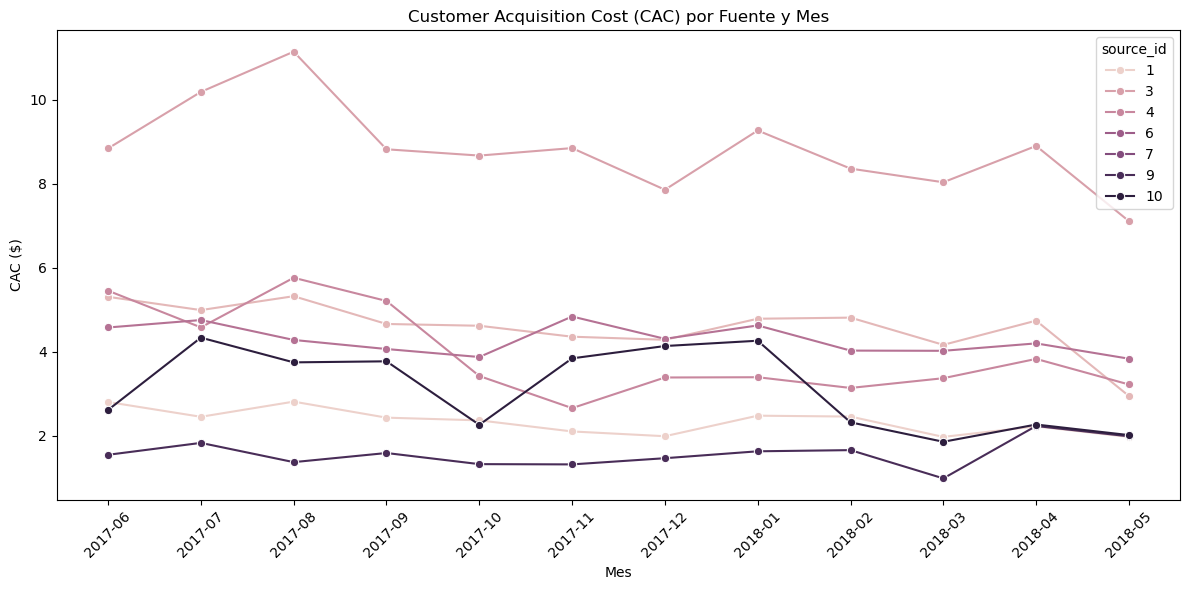

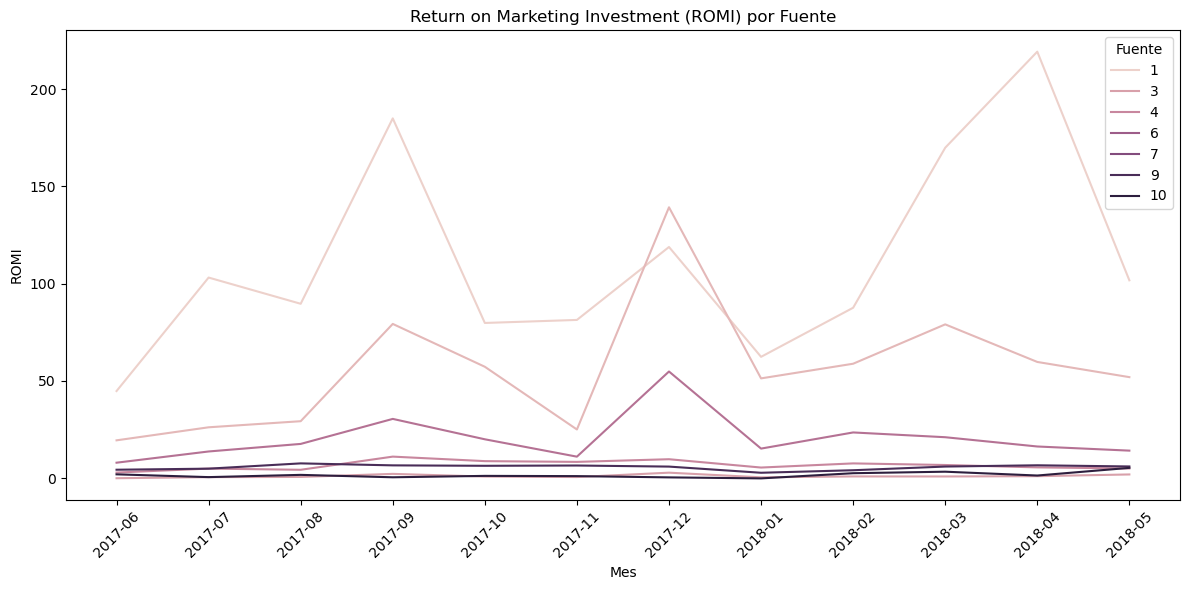

In [49]:
import os
import matplotlib.pyplot as plt



# Función para guardar las gráficas
def save_plot(fig, filename):
    fig.savefig(f'../reports/figures/{filename}', bbox_inches='tight')

# Paso 1: DAU, WAU, MAU
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
ax[0].plot(dau)
ax[0].set(title='DAU', xlabel='Fecha', ylabel='Visitantes')
ax[1].plot(wau)
ax[1].set(title='WAU', xlabel='Semana', ylabel='Visitantes')
ax[2].plot(mau)
ax[2].set(title='MAU', xlabel='Mes', ylabel='Visitantes')

fig.autofmt_xdate(rotation=30)
save_plot(fig, 'dau_wau_mau.png')

# Paso 2: Número de Sesiones por Día
plt.figure(figsize=(12, 6))
sns.lineplot(data=sesiones_por_usuario, x=sesiones_por_usuario.index, y='n_sesion', marker='o')
plt.title('Número de Sesiones por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Sesiones')
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(plt, 'sesiones_por_dia.png')

# Paso 3: Duración de la Sesión
plt.figure(figsize=(12, 6))
sns.histplot(df_visits['duracion_sesion_seg'], bins=50, kde=True)
plt.title('Distribución de la Duración de las Sesiones')
plt.xlabel('Duración de la Sesión (segundos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
save_plot(plt, 'duracion_sesion.png')

# Paso 4: Frecuencia de Regreso de los Usuarios
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('Frecuencia de Regreso de los Usuarios', fontsize=16)
plt.xlabel('Categoría de Frecuencia de Regreso', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_plot(plt, 'frecuencia_regreso_usuarios.png')

# Paso 5: Tiempo hasta la Primera Compra
plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_counts.index, y=conversion_counts.values, palette='viridis')
plt.title('Tiempo hasta la Primera Compra desde la Primera Sesión', fontsize=16)
plt.xlabel('Categoría de Conversión', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(plt, 'tiempo_primera_compra.png')

# Paso 6: Total de Pedidos por Mes
plt.figure(figsize=(12, 6))
sns.barplot(data=pedidos_totales_por_mes, x='buy_ts', y='n_pedidos', color='skyblue')
plt.title('Total de Pedidos por Mes', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(plt, 'total_pedidos_por_mes.png')

# Paso 7: Ticket Promedio por Usuario
plt.figure(figsize=(12, 6))
sns.histplot(ticket_promedio['revenue'], bins=30, kde=True, color='skyblue')
plt.title('Distribución del Ticket Promedio por Usuario', fontsize=16)
plt.xlabel('Valor Promedio de Compra ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
save_plot(plt, 'ticket_promedio_usuario.png')

# Paso 8: LTV por Cohorte
plt.figure(figsize=(12, 8))
sns.heatmap(ltv_pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, linecolor='black')
plt.title('LTV por Cohorte')
plt.xlabel('Mes desde la Primera Compra')
plt.ylabel('Mes de la Primera Compra (Cohorte)')
plt.tight_layout()
save_plot(plt, 'ltv_por_cohorte.png')

# Paso 9: Gastos por Fuente a lo Largo del Tiempo
fig, ax = plt.subplots(figsize=(14, 7))
for fuente in gastos_por_mes_fuente['source_id'].unique():
    fuente_data = gastos_por_mes_fuente[gastos_por_mes_fuente['source_id'] == fuente]
    ax.plot(fuente_data['mes'].astype(str), fuente_data['costs'], label=fuente)

ax.set_title('Gastos por Fuente a lo Largo del Tiempo')
ax.set_xlabel('Mes')
ax.set_ylabel('Gastos ($)')
ax.legend(title='Fuente')
plt.xticks(rotation=45)
save_plot(fig, 'gastos_por_fuente.png')

# Paso 10: CAC por Fuente y Mes
plt.figure(figsize=(12, 6))
sns.lineplot(data=gastos_y_compradores, x='mes', y='cac', hue='source_id', marker='o')
plt.title('Customer Acquisition Cost (CAC) por Fuente y Mes')
plt.xlabel('Mes')
plt.ylabel('CAC ($)')
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(plt, 'cac_por_fuente.png')

# Paso 11: ROMI por Fuente
plt.figure(figsize=(12, 6))
sns.lineplot(data=romi, x='mes', y='romi', hue='source_id')
plt.title('Return on Marketing Investment (ROMI) por Fuente')
plt.xlabel('Mes')
plt.ylabel('ROMI')
plt.legend(title='Fuente')
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(plt, 'romi_por_fuente.png')

print("Todas las gráficas han sido guardadas en la carpeta '../report/figures/'")
